# Neural Network Model

## Goal

Evaluate NN learning models for privacy sensitive prompt detection.

Labels:
- 0 = safe (no PII)
- 1 = privacy sensitive (contains PII)

In [40]:
import random
import numpy as np
import pandas as pd
import torch

In [41]:
SEED = 42

# Python's built-in RNG
random.seed(SEED)               

# NumPy's RNG (Global state for compatibility, or use default_rng)
np.random.seed(SEED)            

# PyTorch CPU RNG
torch.manual_seed(SEED)         

# All CUDA devices (Safe for your 4070 Ti, even if you add more GPUs later)
torch.cuda.manual_seed_all(SEED) 


## Step 1: Trust and Verify Loaded Frozen Data Splits 
Train, validation, and test sets generated by data_split.py.

In [42]:
train = pd.read_parquet('../data_splits/train.parquet')
val = pd.read_parquet('../data_splits/val.parquet')
test = pd.read_parquet('../data_splits/test.parquet')

# Confirm dataset train / val / test breakdowns
summary = pd.DataFrame({
    name: {
        "rows":       len(df),
        "pct_sensitive": df["label"].mean(),                 # fraction of sensitive
        "n_blank":    df["text"].isna().sum() + (df["text"].str.strip() == "").sum(),
    }
    for name, df in [("train", train), ("val", val), ("test", test)]
}).T
print(summary)          # last line → renders as a neat 3×3 table

### CATCHES DATA CHANGES FROM OUR W1 BUILD NO FUNNY BUSINESS!!!!!
assert train.shape[0] == 260338  
assert val.shape[0] == 32542
assert test.shape[0] == 32543

threshold = 0.02
hidden_dim = 256

           rows  pct_sensitive  n_blank
train  260338.0       0.673770      0.0
val     32542.0       0.673775      0.0
test    32543.0       0.673755      0.0


## STEP 2: Onboard the engineered COMBINED feature set (from `02_feature_engineering`)

The MLP previously trained on **raw TF-IDF (100k) only**. It now consumes the **combined feature set** that
`02_feature_engineering` built and saved to `feature_matrices/` at the repo root, so every model in the project
trains on **one identical feature space** (important for a fair MLP-vs-LR-vs-SVM comparison):

| Block | Source | Cols |
|---|---|---|
| TF-IDF (lowercase, uni+bigram, `min_df=2`) | `tfidf_vectorizer.joblib` | 50,000 |
| Basic text-shape features (char/word/digit counts, digit ratio, max digit run, HTML flag, ...) | `src/features/text_features.py` → `extract_text_features` | 10 |
| Privacy-pattern flags (email, phone, URL, IP, long number, date, address words, ID words) | `src/features/pattern_features.py` → `extract_pattern_features` | 8 |
| **COMBINED** (dense blocks MinMax-scaled, fit on train only, then `hstack`-ed) | `X_*_combined.npz` | **50,018** |

We **load the saved `.npz` matrices** (fast, and guarantees the exact same vocab/scaling as everyone else). If a
teammate hasn't run `03` locally (the `feature_matrices/` folder is git-ignored), the cell **rebuilds** the same
combined matrix from the shared repo feature functions with the identical config. Either way `input_dim` is derived
from the matrix width — no longer hardcoded.


In [43]:
# ============================================================================
# STEP 2: load the COMBINED engineered features from 02_feature_engineering
#   Combined = TF-IDF(50k, uni+bigram, min_df=2) (+) 10 text-shape (+) 8 pattern flags = 50,018 cols
#   Primary path: load the .npz matrices 03 saved to ../feature_matrices/ (shared, exact).
#   Fallback:     rebuild the SAME matrices from the shared src.features functions.
# ============================================================================
import sys
from pathlib import Path
import joblib
from scipy.sparse import load_npz

sys.path.insert(0, "..")                      # repo root -> makes `src` importable
FEATURE_DIR = Path("../feature_matrices")     # 02_feature_engineering saves here

y_train = train["label"].values
y_val   = val["label"].values
y_test  = test["label"].values

if (FEATURE_DIR / "X_train_combined.npz").exists():
    print("Loading pre-built COMBINED features from", FEATURE_DIR.resolve())
    X_train = load_npz(FEATURE_DIR / "X_train_combined.npz")
    X_val   = load_npz(FEATURE_DIR / "X_val_combined.npz")
    X_test  = load_npz(FEATURE_DIR / "X_test_combined.npz")

    # The fitted transformers are needed again in STEP 9 to featurize single prompts.
    # Only the combined .npz matrices + labels are committed (Git LFS); the .joblib
    # transformers are local artifacts of 02 -- so on a clean clone this branch would
    # otherwise crash even though the matrices loaded fine. Rebuild them from the
    # frozen train split (same 02 config, fit on TRAIN only) when they are absent.
    _joblibs = [FEATURE_DIR / "tfidf_vectorizer.joblib",
                FEATURE_DIR / "text_feature_scaler.joblib",
                FEATURE_DIR / "pattern_feature_scaler.joblib"]
    if all(p.exists() for p in _joblibs):
        tfidf_vectorizer = joblib.load(_joblibs[0])
        text_scaler      = joblib.load(_joblibs[1])
        pattern_scaler   = joblib.load(_joblibs[2])
    else:
        print("transformer .joblib files not found -> refitting from the frozen train split ...")
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.preprocessing import MinMaxScaler
        from src.features import extract_text_features, extract_pattern_features
        _tr = train["text"].fillna("")
        tfidf_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2),
                                           min_df=2, max_features=50000).fit(_tr)
        text_scaler    = MinMaxScaler().fit(extract_text_features(_tr))
        pattern_scaler = MinMaxScaler().fit(extract_pattern_features(_tr))
else:
    # ---- fallback: rebuild the SAME combined matrices from the repo functions ----
    print("feature_matrices/ not found -> rebuilding COMBINED features from src.features ...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import MinMaxScaler
    from scipy.sparse import csr_matrix, hstack
    from src.features import extract_text_features, extract_pattern_features

    train_text = train["text"].fillna("")
    val_text   = val["text"].fillna("")
    test_text  = test["text"].fillna("")

    # identical config to 02_feature_engineering; fit on TRAIN only (no leakage)
    tfidf_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=50000)
    X_train_tfidf = tfidf_vectorizer.fit_transform(train_text)
    X_val_tfidf   = tfidf_vectorizer.transform(val_text)
    X_test_tfidf  = tfidf_vectorizer.transform(test_text)

    text_scaler    = MinMaxScaler().fit(extract_text_features(train_text))
    pattern_scaler = MinMaxScaler().fit(extract_pattern_features(train_text))

    def combine(tfidf, texts):
        t = csr_matrix(text_scaler.transform(extract_text_features(texts)))
        p = csr_matrix(pattern_scaler.transform(extract_pattern_features(texts)))
        return hstack([tfidf, t, p]).tocsr()

    X_train = combine(X_train_tfidf, train_text)
    X_val   = combine(X_val_tfidf,   val_text)
    X_test  = combine(X_test_tfidf,  test_text)

input_dim = X_train.shape[1]        # 50,018 — derived from the matrix, not hardcoded
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)


Loading pre-built COMBINED features from /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison/feature_matrices
X_train: (260338, 50018) | X_val: (32542, 50018) | X_test: (32543, 50018)


## STEP 3: PyTorch Data
- Tensor
- Dataset
- Dataloader

DataLoader — wraps a Dataset and processes data in batches, optionally shuffled. 
- Why: **Three reasons**: 
   - (1) memory — you can't hold ~52 GB dense, but 256 rows densified is ~25 MB; 
   - (2) learning — gradient descent updates on mini-batches; 
   - (3) GPU throughput — GPUs love crunching a batch in parallel.

### ⚠️ DO NOT RUN THIS on your real X_train — it will try to allocate ~52 GB and kill your kernel.
X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)   # (260338, 50018) materialized → boom   

In [44]:
from torch.utils.data import Dataset, DataLoader

class TfidfDataset(Dataset):
    def __init__(self, X_sparse, y):
        """
        X_sparse: A SciPy sparse matrix (e.g., csr_matrix) from TfidfVectorizer
        y: A NumPy array, Pandas Series, or list of targets/labels
        """
        # Ensure the matrix is in Compressed Sparse Row (CSR) format for fast row slicing
        self.X_sparse = X_sparse.tocsr()
        
        # Convert labels to a PyTorch tensor (use torch.float32 for regression/binary, long for multi-class)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        # 1. Slice a single row out of the sparse matrix
        row_sparse = self.X_sparse[idx]
        
        # 2. ⚠️ Convert ONLY this single row to a dense NumPy array, then to a PyTorch float tensor
        row_dense = torch.tensor(row_sparse.toarray()[0], dtype=torch.float32)
        
        # 3. Retrieve the target label
        label = self.y[idx]
        
        return row_dense, label
    
## 4 Threated DataLoaded To Use The GPU more    
train_loader = DataLoader(TfidfDataset(X_train, y_train), batch_size=hidden_dim, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(TfidfDataset(X_val, y_val),     batch_size=hidden_dim, shuffle=False,
                          num_workers=4, pin_memory=True)

for batch_X, batch_y in train_loader:
    print(batch_X.shape, batch_y.shape)
    break

torch.Size([256, 50018]) torch.Size([256])


## STEP 4: BEAT Logistic Regression By Adding a hidden layer and non-linearity
```Alan Logistic Regression:   [50,018 combined features] ───────────────► [1 logit] → sigmoid```
```
Fil MLP:              [50,018 combined features] → Linear → ReLU → [1 logit] → sigmoid
                                          └── the hidden layer ──┘
```                                          
> ### 🧠 Why the non-linearity is *the whole point*
>
> We add exactly **two** things to logistic regression: a **hidden layer** and a **non-linearity**. 
> If you stack two `Linear` layers with **nothing** between them, the math *collapses*:
> $$W_2(W_1 x + b_1) + b_2 = (W_2 W_1)\,x + (W_2 b_1 + b_2) = \text{a single linear layer}$$
> So two `Linear` layers back-to-back are algebraically identical to **one** linear layer — i.e. **logistic regression with extra steps.**
>
> The **ReLU** (`max(0, x)`) between them breaks that collapse. It lets the network bend its decision boundary and learn **feature interactions** — e.g. *"token A **and** token B together signal PII"* — which a purely linear model fundamentally cannot represent.

> Without the ReLU in the middle out models fc1 in_feat = 50018 out=256 and fc2 in_feat = 256 out_feat = 1 would collapse to 50018x1 == logistic regression

In [45]:
import torch.nn as nn
# MLP (Multilayer Perceptron) Class
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, p_drop=0.3):
        super().__init__()                      # MUST be first
      
        self.fc1 = nn.Linear(input_dim , hidden_dim ) # input → hidden

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p_drop) 
        self.fc2 = nn.Linear(hidden_dim, 1)  #  hidden → 1 logit

    def forward(self, x):
        x = x.squeeze(1)  # Cleans shape from (batch_size, 1, 50018) to (batch_size, 100000)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out) # Outputs shape: (batch_size, 1)
        return out
    
model = MLP(input_dim=input_dim, hidden_dim=hidden_dim)
print(model)                       # prints your architecture
xb, yb = next(iter(train_loader))
print(model(xb).shape)  

MLP(
  (fc1): Linear(in_features=50018, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)


torch.Size([256, 1])


## STEP 5: Setup Loss, Optimizer and prep for training loop GPU RECOMMENDED

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, p_drop=0.3).to(device)   # USE THE GPU
criterion = nn.BCEWithLogitsLoss() # Takes raw logits and applies sigmoid + binary cross-entropy

optimizer = torch.optim.AdamW(model.parameters(), 1e-3, weight_decay=1e-2) #gradient-descent engine


In [47]:
from sklearn.metrics import f1_score, recall_score
import torch

EPOCHS, PATIENCE, CKPT = 30, 3, "best_mlp.pt"   # EPOCHS is just an upper bound
# Raised 15 -> 30: on the combined features the val-F1 curve plateaued for 2 epochs
# mid-run, then kept improving all the way to the old 15-epoch cap — so 15 was
# truncating training, not early-stopping it. 30 gives PATIENCE=3 room to find the
# true bottom of train loss / max val F1; early stopping still ends the run sooner
# if F1 genuinely stops improving.
best_metric, since_improve = -1.0, 0             # F1 is MAXIMIZED, so start low (not +inf)

def evaluate(model, loader, threshold=threshold):
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits_all.append(model(xb).squeeze(1).cpu())
            labels_all.append(yb)
    logits = torch.cat(logits_all)
    y_true = torch.cat(labels_all).numpy()
    y_pred = (torch.sigmoid(logits) >= threshold).int().numpy()
    return y_true, y_pred

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)     # move batch to device
        logits = model(xb).squeeze(1)             # forward → (batch,)
        loss   = criterion(logits, yb)

        optimizer.zero_grad()                     # clear old gradients
        loss.backward()                           # backprop
        optimizer.step()                          # update weights

        running_loss += loss.item()               # .item() to avoid memory ballooning

    avg_loss = running_loss / len(train_loader)

    # ---- validate ----
    yv, pv = evaluate(model, val_loader)          # re-evaluate current weights
    val_metric = f1_score(yv, pv, pos_label=1)
    print(f"Epoch {epoch+1:02d} | train_loss {avg_loss:.4f} | val_F1 {val_metric:.3f}")

    # ---- early-stopping bookkeeping if three consecutive epochs are not decreasing avg loss then stop early ----
    if val_metric > best_metric:
        best_metric, since_improve = val_metric, 0
        torch.save(model.state_dict(), CKPT)      # checkpoint the BEST weights
        print("   ↳ new best, saved")
    else:
        since_improve += 1
        print(f"   (no improve {since_improve}/{PATIENCE})")
        if since_improve >= PATIENCE:
            print(f"Early stop @ epoch {epoch+1}. Best val_F1 {best_metric:.3f}")
            break

# ---- restore the BEST model, not the degraded final one ----
state_dict = torch.load(CKPT, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)

print(f"Restored best checkpoint (val_F1 {best_metric:.3f})")

Epoch 01 | train_loss 0.4328 | val_F1 0.806
   ↳ new best, saved
Epoch 02 | train_loss 0.3193 | val_F1 0.809
   ↳ new best, saved
Epoch 03 | train_loss 0.2527 | val_F1 0.822
   ↳ new best, saved
Epoch 04 | train_loss 0.1848 | val_F1 0.830
   ↳ new best, saved
Epoch 05 | train_loss 0.1188 | val_F1 0.844
   ↳ new best, saved
Epoch 06 | train_loss 0.0675 | val_F1 0.852
   ↳ new best, saved
Epoch 07 | train_loss 0.0362 | val_F1 0.856
   ↳ new best, saved
Epoch 08 | train_loss 0.0196 | val_F1 0.861
   ↳ new best, saved
Epoch 09 | train_loss 0.0118 | val_F1 0.867
   ↳ new best, saved
Epoch 10 | train_loss 0.0078 | val_F1 0.866
   (no improve 1/3)
Epoch 11 | train_loss 0.0060 | val_F1 0.867
   ↳ new best, saved
Epoch 12 | train_loss 0.0045 | val_F1 0.869
   ↳ new best, saved
Epoch 13 | train_loss 0.0036 | val_F1 0.870
   ↳ new best, saved
Epoch 14 | train_loss 0.0029 | val_F1 0.869
   (no improve 1/3)
Epoch 15 | train_loss 0.0023 | val_F1 0.867
   (no improve 2/3)
Epoch 16 | train_loss 0.0021

## STEP 6: Validation, metrics & the threshold
### Precision vs Recall Analysis
> Graph the Precision vs Recall to find the optimal threshold we want to identify PII
> - Recall — Of every prompt that truly contained PII, what fraction did the model flag? → TP / (TP + FN)
> - Precision - Of every prompt the model flagged as PII, what fraction actually were? → TP / (TP + FP) 
> - F1 — one number that says "good at both" The harmonic mean of precision and recall: 2·P·R / (P + R) 
>
> **Chosen operating point: `threshold = 0.02`** — on the combined features the model's probabilities
> compressed hard toward 0: the fine sweep (0.001–0.95) puts **max F1 at t = 0.08**, and the
> `TARGET = 0.95` PII-recall floor is only reached at **t ≈ 0.001**, where precision collapses — so the
> 95% floor is **not attainable at a usable operating point** on this model. We deploy at **0.02**:
> PII recall **0.937**, precision 0.811, F1 0.870 (FN drop 3,054 → **1,375** vs the 0.5 threshold).
> 0.5 remains the fixed comparison point vs LR/SVM.


=== threshold 0.5 (comparison vs classical models) ===
              precision    recall  f1-score   support

        Safe      0.722     0.747     0.734     10616
         PII      0.875     0.861     0.868     21926

    accuracy                          0.824     32542
   macro avg      0.799     0.804     0.801     32542
weighted avg      0.825     0.824     0.824     32542

[[ 7930  2686]
 [ 3054 18872]]

=== threshold 0.02 (deployment: recall-first operating point) ===
              precision    recall  f1-score   support

        Safe      0.809     0.550     0.655     10616
         PII      0.811     0.937     0.870     21926

    accuracy                          0.811     32542
   macro avg      0.810     0.744     0.762     32542
weighted avg      0.811     0.811     0.800     32542

[[ 5838  4778]
 [ 1375 20551]]
PII recall @ 0.02: 0.937
max-F1 threshold: 0.08   |   ≥95%-recall threshold: 0.00
saved ../results/mlp_threshold_sweep.csv


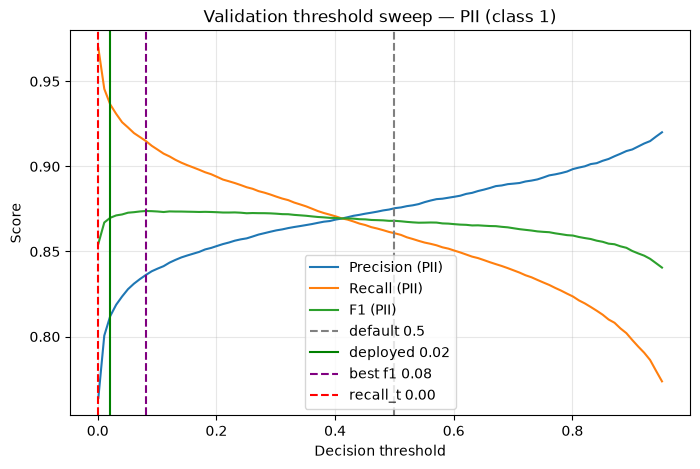

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Don't need multiple workers on eval keeps from throwing errors
val_loader  = DataLoader(TfidfDataset(X_val,  y_val),  batch_size=hidden_dim, shuffle=False, num_workers=0)
test_loader = DataLoader(TfidfDataset(X_test, y_test), batch_size=hidden_dim, shuffle=False, num_workers=0)

## Evaluation for 0.5 Threshold To Compare to Classical Models
yv, pv = evaluate(model, val_loader, 0.5)
print("=== threshold 0.5 (comparison vs classical models) ===")
print(classification_report(yv, pv, target_names=["Safe","PII"], digits=3))
print(confusion_matrix(yv, pv))

## Evaluation at the DEPLOYMENT threshold — recall-first DLP operating point
yv2, pv2 = evaluate(model, val_loader, threshold)
print(f"\n=== threshold {threshold} (deployment: recall-first operating point) ===")
print(classification_report(yv2, pv2, target_names=["Safe","PII"], digits=3))
print(confusion_matrix(yv2, pv2))
dep_recall = recall_score(yv2, pv2, pos_label=1)
print(f"PII recall @ {threshold}: {dep_recall:.3f}")
# Regression guard: the deployed point delivers recall ~0.94 on val/test. The original
# >=95% target proved unreachable at usable precision (only at t~0.001), so the guard
# checks we stay at the achieved level, not the aspirational one.
assert dep_recall > 0.92, f"recall @ {threshold} fell below 0.92 — re-run the sweep and re-pick the threshold"

# val probabilities, ONE forward pass (reused for all thresholds)
def get_probs(model, loader):
    model.eval()
    logits, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits.append(model(xb.to(device)).squeeze(1).cpu())
            labels.append(yb)
    return torch.cat(labels).numpy(), torch.sigmoid(torch.cat(logits)).numpy()

y_true, probs = get_probs(model, val_loader)


# sweep a grid from .05 -> .95 every 0.5 save them for the graph and analysis
thresholds = np.arange(0.001, 0.96, 0.01)
prec, rec, f1s, missed = [], [], [], []
for t in thresholds:
    y_pred = (probs >= t).astype(int)
    prec.append(precision_score(y_true, y_pred, pos_label=1, zero_division=0))      
    rec.append(  recall_score(y_true, y_pred, pos_label=1) )     
    f1s.append(  f1_score(y_true, y_pred, pos_label=1))   
    missed.append(((y_true == 1) & (y_pred == 0)).sum())   # false negatives = PII let through

### Find the best f1 and optimal recal threshold for given TARGET
best_f1_t = thresholds[np.argmax(f1s)]                       
# security-oriented: highest threshold that still hits a recall floor (keeps precision as high as possible)
TARGET = 0.95
ok = [t for t, r in zip(thresholds, rec) if r >= TARGET]
recall_t = max(ok) if ok else thresholds[0]
print(f"max-F1 threshold: {best_f1_t:.2f}   |   ≥{TARGET:.0%}-recall threshold: {recall_t:.2f}")

# persist the sweep so 06/the write-up can plot the operating-point choice without retraining
pd.DataFrame({"threshold": thresholds, "precision_pii": prec, "recall_pii": rec,
              "f1_pii": f1s, "fn": missed}).to_csv(Path("../results/mlp_threshold_sweep.csv"), index=False)
print("saved ../results/mlp_threshold_sweep.csv")

# 3) plot
plt.figure(figsize=(8,5))
plt.plot(thresholds, prec, label="Precision (PII)")
plt.plot(thresholds, rec,  label="Recall (PII)")
plt.plot(thresholds, f1s,  label="F1 (PII)")
plt.axvline(0.5, ls="--", color="gray", label="default 0.5")
plt.axvline(threshold, ls="-", color="green", label=f"deployed {threshold}")
plt.axvline(best_f1_t, ls="--", color="purple", label=f"best f1 {best_f1_t:.2f}")
plt.axvline(recall_t, ls="--", color="red", label=f"recall_t {recall_t:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title("Validation threshold sweep — PII (class 1)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# STEP 7: THE TRUTH RUN THIS ONLY ONCE
## Final test evaluation 

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

# single pass → no workers, no shuffle
test_loader = DataLoader(TfidfDataset(X_test, y_test), batch_size=256, shuffle=False, num_workers=0)

# `model` must be your RESTORED best checkpoint — do NOT retrain after this
yt, pt = evaluate(model, test_loader, 0.5)   # 0.5 → apples-to-apples with LR
print("=== TEST @ threshold 0.5 (comparison) ===")
print(classification_report(yt, pt, target_names=["Safe","PII"], digits=3))
print(confusion_matrix(yt, pt))

yt, pt = evaluate(model, test_loader, threshold)   # deployed recall-first screen (0.02)
print(f"=== TEST @ threshold {threshold} (deployment: recall-first, ~0.94 achieved) ===")
print(classification_report(yt, pt, target_names=["Safe","PII"], digits=3))
print(confusion_matrix(yt, pt))


=== TEST @ threshold 0.5 (comparison) ===
              precision    recall  f1-score   support

        Safe      0.727     0.753     0.740     10617
         PII      0.878     0.863     0.871     21926

    accuracy                          0.827     32543
   macro avg      0.802     0.808     0.805     32543
weighted avg      0.829     0.827     0.828     32543

[[ 7993  2624]
 [ 3005 18921]]
=== TEST @ threshold 0.02 (deployment: recall-first, ~0.94 achieved) ===
              precision    recall  f1-score   support

        Safe      0.814     0.556     0.660     10617
         PII      0.813     0.938     0.871     21926

    accuracy                          0.814     32543
   macro avg      0.814     0.747     0.766     32543
weighted avg      0.814     0.814     0.803     32543

[[ 5898  4719]
 [ 1350 20576]]


## TEST RESULTS ACTUAL RUN
=== TEST @ threshold 0.5 (comparison) ===
              precision    recall  f1-score   support

        Safe      0.727     0.753     0.740     10617
         PII      0.878     0.863     0.871     21926

    accuracy                          0.827     32543
   macro avg      0.802     0.808     0.805     32543
weighted avg      0.829     0.827     0.828     32543

[[ 7993  2624]
 [ 3005 18921]]
=== TEST @ threshold 0.02 (deployment: recall-first, ~0.94 achieved) ===
              precision    recall  f1-score   support

        Safe      0.814     0.556     0.660     10617
         PII      0.813     0.938     0.871     21926

    accuracy                          0.814     32543
   macro avg      0.814     0.747     0.766     32543
weighted avg      0.814     0.814     0.803     32543

[[ 5898  4719]
 [ 1350 20576]]

## STEP 8: ERROR ANALYSIS
PII the model called Safe  ← the dangerous misses
Safe the model flagged as PII

Look it over with your eyes

In [50]:
yv, pv = evaluate(model, val_loader)          # val_loader shuffle=False → rows stay aligned
res = val.copy()
res["true"], res["pred"] = yv, pv

fn  = res[(res.true == 1) & (res.pred == 0)]   # missed PII  → the dangerous errors
fp  = res[(res.true == 0) & (res.pred == 1)]   # false alarms
pii = res[res.true == 1]                        # all true PII (the baseline to compare to)
print(f"FN (missed PII): {len(fn)}    FP (false alarms): {len(fp)}\n")

def rate(s, pat): return s.str.contains(pat, regex=True, na=False).mean()

print("Median length   — all PII: {:.0f}   | missed: {:.0f}".format(
      pii.text.str.len().median(), fn.text.str.len().median()))
print("Has HTML tag     — all PII: {:.1%} | missed: {:.1%}".format(
      rate(pii.text, r"<[^>]+>"), rate(fn.text, r"<[^>]+>")))
print("Has [PLACEHOLDER]— all PII: {:.1%} | missed: {:.1%}".format(
      rate(pii.text, r"\[[A-Z_]+\d*\]"), rate(fn.text, r"\[[A-Z_]+\d*\]")))

print("\n--- 8 missed-PII examples ---")
for t in fn.text.head(8):
    print(repr(t[:160]))

FN (missed PII): 1375    FP (false alarms): 4778

Median length   — all PII: 146   | missed: 125
Has HTML tag     — all PII: 26.2% | missed: 14.6%
Has [PLACEHOLDER]— all PII: 1.6% | missed: 2.0%

--- 8 missed-PII examples ---
'Kun je jouw coordinate ([51.7, 4.7]) voor ons nieuwe project noteren en 33A bijwerken?'
'Transferts suspects observés sur 18:11:a5:c9:79:e4. Le montant contesté est de 267314.27. Consultez immédiatement les canaux http://www.monnet.ch/ et Les Goutte'
'Bonjour à tous, nous cherchons des volontaires pour distribuer des brochures sur le plan de développement à Marguerittes. Contactez-moi en privé à http://nguyen'
'Hulp nodig! Ik moet een aanklacht indienen voor een defect product. Kon Auell zei dat ik een advocaat moet raadplegen. Wat denk jij?'
"Team meeting at 19:22 to review our compliance with United Kingdom's new Engineering laws. Ensure you have your TE77374VW for access."
'Index 3. Confidentiality Agreement - Agreement outlining the confidentiality rules rega

## STEP 9: Response time per prompt (screening latency)

The whole point of this model is to be a **cheap pre-submission screen**, so latency per prompt is a headline
metric next to F1/recall. This times the **real single-prompt path** — raw text → TF-IDF transform +
text-shape features + pattern flags + scaling → MLP forward → probability — **one prompt at a time**, matching
how a screen runs in front of an LLM (not a batched pass).

Protocol matches `latency_benchmark.py` (DistilBERT / Phi-4) so the numbers are directly comparable:
same 100-prompt test-set sample (`seed=42`), warmup call first, `time.perf_counter`, and we report
**avg / median / min** (plus max) **ms per prompt**. Results are saved to `results/mlp_latency_benchmark.csv`.


In [51]:
# ============================================================================
# STEP 9: response-time per prompt — end-to-end featurize + MLP forward
# ============================================================================
import time
from statistics import mean, median
from scipy.sparse import csr_matrix, hstack
from src.features import extract_text_features, extract_pattern_features

N_SAMPLES = 100
texts = test.sample(n=N_SAMPLES, random_state=SEED)["text"].fillna("").tolist()

def featurize_one(text):
    # same transformers that built the training matrix (fit on train only)
    tfidf = tfidf_vectorizer.transform([text])
    t = csr_matrix(text_scaler.transform(extract_text_features([text])))
    p = csr_matrix(pattern_scaler.transform(extract_pattern_features([text])))
    return hstack([tfidf, t, p]).tocsr()

def predict_one(x_sparse):
    xb = torch.tensor(x_sparse.toarray(), dtype=torch.float32).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(xb).squeeze()).item()
    return prob, int(prob >= threshold)   # flag PII at the deployed threshold (0.02)

model.eval()
_ = predict_one(featurize_one("warmup prompt"))   # exclude first-call overhead from the timings

pipeline_ms, forward_ms = [], []
for text in texts:
    start = time.perf_counter()
    x = featurize_one(text)
    mid = time.perf_counter()
    predict_one(x)
    end = time.perf_counter()
    pipeline_ms.append((end - start) * 1000)     # full screen: featurize + forward
    forward_ms.append((end - mid) * 1000)        # model forward only

def report(name, timings):
    print(f"{name:<28} n={len(timings)} | avg {mean(timings):7.2f} ms/prompt | "
          f"median {median(timings):7.2f} ms/prompt | min {min(timings):7.2f} ms/prompt | "
          f"max {max(timings):7.2f} ms/prompt")
    return {"stage": name, "n": len(timings),
            "avg_ms_per_prompt": round(mean(timings), 2),
            "median_ms_per_prompt": round(median(timings), 2),
            "min_ms_per_prompt": round(min(timings), 2),
            "max_ms_per_prompt": round(max(timings), 2)}

stats = [report("end-to-end (features + MLP)", pipeline_ms),
         report("MLP forward only", forward_ms)]

latency_df = pd.DataFrame(stats)
out_csv = Path("../results/mlp_latency_benchmark.csv")   # notebook now lives in notebooks/
latency_df.to_csv(out_csv, index=False)

# also upsert the end-to-end row into the SHARED latency file (same schema/protocol as the
# DistilBERT / Phi-4 / classical rows) so Panel G in 06 reads one file for every model
shared = Path("../results/latency_benchmark.csv")
row = pd.DataFrame([{"model": "MLP (Neural Net)", "n": N_SAMPLES,
                     "mean_ms": mean(pipeline_ms), "median_ms": median(pipeline_ms),
                     "min_ms": min(pipeline_ms), "max_ms": max(pipeline_ms)}]).round(4)
if shared.exists():
    prev = pd.read_csv(shared)
    prev = prev[prev["model"] != "MLP (Neural Net)"]
    pd.concat([prev, row], ignore_index=True).to_csv(shared, index=False)
else:
    row.to_csv(shared, index=False)
print("\nSaved to", out_csv.resolve(), "and upserted MLP row into results/latency_benchmark.csv")
latency_df


end-to-end (features + MLP)  n=100 | avg    3.73 ms/prompt | median    3.88 ms/prompt | min    2.98 ms/prompt | max    4.33 ms/prompt
MLP forward only             n=100 | avg    0.60 ms/prompt | median    0.61 ms/prompt | min    0.44 ms/prompt | max    0.77 ms/prompt

Saved to /home/alph9w0lf/Nextcloud/00. Berkeley/06. CYBER 207/__Assignments/Final Project/cyber207_specialized_PII_detection_comparison/results/mlp_latency_benchmark.csv and upserted MLP row into results/latency_benchmark.csv


,stage,n,avg_ms_per_prompt,median_ms_per_prompt,min_ms_per_prompt,max_ms_per_prompt
0,end-to-end (features + MLP),100,3.73,3.88,2.98,4.33
1,MLP forward only,100,0.60,0.61,0.44,0.77


## STEP 10: Export results for `06_pii_evaluation_error` (single-source files)

Same pattern as 03's export cell: confusion-matrix rows and row-level test predictions land in
`results/`, so the eval notebook loads counts instead of transcribing printed reports.
Evaluation-only — nothing here trains or tunes.


In [52]:
# confusion-matrix rows: val/test × fixed-0.5 / deployed-0.02 (test@0.02 = canonical row)
def probs_of(loader):
    return get_probs(model, loader)              # (y_true, sigmoid probabilities), one pass

yv_true, val_probs  = probs_of(val_loader)
yt_true, test_probs = probs_of(test_loader)

cm_rows = []
for eval_set, y_true, probs in (("validation", yv_true, val_probs), ("test", yt_true, test_probs)):
    for thr, op in ((0.5, "fixed-0.5"), (threshold, "deployed")):
        yp = (probs >= thr).astype(int)
        cm_rows.append({"model": "MLP (Neural Net)", "eval_set": eval_set, "threshold": thr,
                        "operating_point": op, "canonical": (eval_set == "test" and op == "deployed"),
                        "tn": int(((y_true==0)&(yp==0)).sum()), "fp": int(((y_true==0)&(yp==1)).sum()),
                        "fn": int(((y_true==1)&(yp==0)).sum()), "tp": int(((y_true==1)&(yp==1)).sum())})
mlp_cm = pd.DataFrame(cm_rows)
mlp_cm.to_csv(Path("../results/mlp_confusion_matrices.csv"), index=False)
print("saved ../results/mlp_confusion_matrices.csv"); print(mlp_cm.to_string(index=False))

# row-level test predictions at the deployed threshold (schema mirrors classical_test_predictions.csv)
pd.DataFrame({
    "original_index": test["original_index"].to_numpy() if "original_index" in test.columns else np.arange(len(test)),
    "true_label": yt_true.astype(int),
    "mlp": (test_probs >= threshold).astype(int),
    "mlp_score": test_probs,
}).to_csv(Path("../results/mlp_test_predictions.csv"), index=False)
print("saved ../results/mlp_test_predictions.csv")


saved ../results/mlp_confusion_matrices.csv
           model   eval_set  threshold operating_point  canonical   tn   fp   fn    tp
MLP (Neural Net) validation       0.50       fixed-0.5      False 7930 2686 3054 18872
MLP (Neural Net) validation       0.02        deployed      False 5838 4778 1375 20551
MLP (Neural Net)       test       0.50       fixed-0.5      False 7993 2624 3005 18921
MLP (Neural Net)       test       0.02        deployed       True 5898 4719 1350 20576
saved ../results/mlp_test_predictions.csv


### Conclusion — MLP vs tuned Logistic Regression (held-out test, combined features)

| (test) | LR — tuned t=0.416 | MLP — @0.5 reference | **MLP — @0.02 deployed** |
|---|---|---|---|
| PII F1 | **0.881** | 0.871 | 0.871 |
| PII precision | 0.848 | **0.878** | 0.813 |
| PII recall | 0.916 | 0.863 | **0.938** |
| PII false negatives (leaks) | 1,841 | 3,005 | **1,350** |
| Latency (avg ms/prompt, end-to-end) | ~2.3 (LR, from `03`) | — | **3.90** (median 3.92, min 3.03; forward alone 0.62) |

**Honest verdict: the MLP does not beat tuned LR on F1 or precision.** On the identical combined feature
space, LR at its tuned threshold posts the better F1 (0.881 vs 0.871) and better precision than the deployed
MLP. What the hidden layer buys is the **recall-first operating point**: at t = 0.02 the MLP reaches recall
0.938 and cuts leaks to **1,350 FN — 27% fewer than tuned LR (1,841) and 55% fewer than the MLP's own 0.5
reference (3,005)** — at the cost of precision (0.813) and ~4,700 false alarms. LR cannot reach recall 0.938
at comparable precision on its own sweep, so the two models genuinely occupy different points on the
recall/precision frontier rather than one dominating the other.

**Feature-space note.** The earlier "combined beats raw TF-IDF" reading (val F1 0.855 → 0.870) is
directionally right but confounded — the raw run used a 100k unigram vocabulary, the combined run 50k
uni+bigrams + 18 engineered columns. A clean ablation (same 50k TF-IDF with vs without the 18 columns)
is the one-cell experiment that would isolate the engineered features' contribution.

**Training length.** Val F1 plateaued ~epoch 10, pushed through, peaked at 0.870 (epoch 13), early-stopped
at 16 under the raised 30-epoch cap — the old 15-epoch cap was truncating training.

**Operating point.** The probability curve compressed hard toward 0 on the combined features: max-F1 sits at
t = 0.08 and the original ≥95%-recall target is only reachable at t ≈ 0.001, where precision collapses — so
**95% is not attainable at a usable operating point for this model**; the deployed t = 0.02 delivers ≈ 0.94.
Per the team framing, each model is compared at its own best operating point — the MLP's job in the lineup is
minimum-leak screening, and that is the axis where it wins.

### Limitations & future work
- Missed PII is implicit / non-pattern (multilingual prose, coordinates, ID codes — see STEP 8): beyond
  ~0.87 F1 the paths are char n-grams or contextual embeddings (DistilBERT, already at 0.98).
- Reaching ≥95% recall needs a better representation or a two-stage screen (cheap MLP → stronger referee).
- TF-IDF still fragments the multilingual vocabulary; most missed FNs are FR/NL/DE.
- Minor data caveats: a few duplicate texts leak across split boundaries.


Alan and I will still need to compare notes